## ALGORITHM 2: LOGISTIC REGRESSION

### Definition
Logistic Regression is used for **classification problems** — predicting categories (Yes/No, Pass/Fail, Spam/Not Spam). Despite "Regression" in its name, it's a classification algorithm that outputs **probabilities between 0 and 1**.

**Mathematical Formula:**
```
P(Y=1) = 1 / (1 + e^(-z))

Where:
z = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ
P(Y=1) = Probability of positive class

Decision Rule:
If P(Y=1) > 0.5 → Predict Class 1
If P(Y=1) ≤ 0.5 → Predict Class 0

    Indian Analogy: Bank Loan Approval 🏦

    Think of how SBI or HDFC Bank decides loan approval:

    Input Features:
        Monthly Income
        CIBIL Score
        Existing Loans
        Age
        Employment Type

    Output: Not "how much loan" (that's regression), but "APPROVED or REJECTED"

                      ┌─────────────────┐
    Income=₹50,000 ───│                 │
    CIBIL=750      ───│   LOGISTIC      │───▶ P(Approved) = 0.85
    Existing=₹2L   ───│   REGRESSION    │───▶ Decision: APPROVED ✅
    Age=35         ───│                 │
                      └─────────────────┘

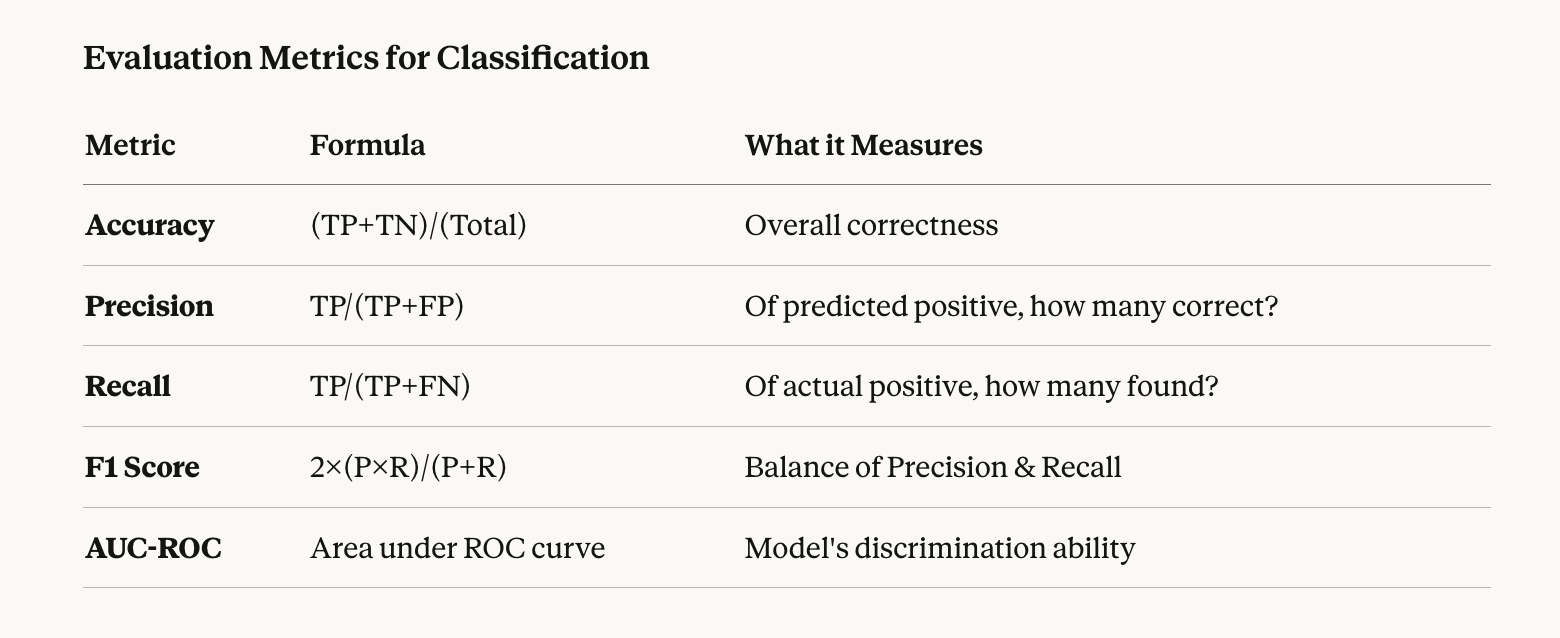

    Indian Analogy: Understanding Confusion Matrix
    Scenario: COVID Testing at Airport 🛫

    Actual COVID Status
                        ┌─────────────┬──────────────┐
                        │  Positive   │  Negative    │
          ┌─────────────┼─────────────┼──────────────┤
    Test  │ Positive    │     TP      │     FP       │
    Result│ (Quarantine)│ (Correct!)  │ (False Alarm)│
          ├─────────────┼─────────────┼──────────────┤
          │ Negative    │     FN      │     TN       │
          │ (Let go)    │ (DANGEROUS!)│ (Correct!)   │
          └─────────────┴─────────────┴──────────────┘

    TP = True Positive  = Has COVID, Test says COVID (✅ Correct)
    TN = True Negative  = No COVID, Test says No COVID (✅ Correct)
    FP = False Positive = No COVID, Test says COVID (❌ Inconvenience)
    FN = False Negative = Has COVID, Test says No COVID (❌ DANGEROUS!)

    Which metric matters more?

    For COVID: Recall (catch all positive cases, even if some false alarms)
    For Spam: Precision (don't mark important emails as spam)

In [1]:
# ============================================================
# LOGISTIC REGRESSION - COMPLETE IMPLEMENTATION WITH EVALUATION
# ============================================================

# Step 1: Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2: Create Dataset - Bank Loan Approval
np.random.seed(42)
n_samples = 500

data = {
    'monthly_income': np.random.randint(20000, 150000, n_samples),
    'cibil_score': np.random.randint(300, 900, n_samples),
    'existing_loan_lakhs': np.random.uniform(0, 50, n_samples),
    'age': np.random.randint(22, 60, n_samples),
    'employment_years': np.random.randint(0, 30, n_samples),
}
df = pd.DataFrame(data)

In [3]:
# Create target (loan approval) based on logical rules + noise
approval_score = (
    (df['monthly_income'] / 10000) +
    (df['cibil_score'] / 100) +
    (df['employment_years'] * 0.5) -
    (df['existing_loan_lakhs'] * 0.3) -
    (df['age'] * 0.1)
)
approval_prob = 1 / (1 + np.exp(-0.5 * (approval_score - approval_score.mean())))
df['loan_approved'] = (approval_prob > 0.5).astype(int)


In [4]:
df

,monthly_income,cibil_score,existing_loan_lakhs,age,employment_years,loan_approved
0,141958,460,5.741841,39,8,1
1,35795,555,30.531002,35,6,0
2,20860,622,14.431528,50,3,0
3,123694,427,29.061911,33,12,1
4,148106,317,7.718136,57,16,1
...,...,...,...,...,...,...
495,86235,417,35.408604,24,14,0
496,74240,524,3.367530,30,19,1
497,144019,831,29.108523,29,26,1
498,85726,412,17.294153,54,17,1


In [5]:
# Add some noise
noise_idx = np.random.choice(n_samples, size=int(n_samples*0.05), replace=False)
df.loc[noise_idx, 'loan_approved'] = 1 - df.loc[noise_idx, 'loan_approved']

print("=== Loan Approval Dataset ===")
print(df.head(10))
print(f"\nClass Distribution:")
print(df['loan_approved'].value_counts())
print(f"Approval Rate: {df['loan_approved'].mean()*100:.1f}%")

=== Loan Approval Dataset ===
   monthly_income  cibil_score  existing_loan_lakhs  age  employment_years  \
0          141958          460             5.741841   39                 8   
1           35795          555            30.531002   35                 6   
2           20860          622            14.431528   50                 3   
3          123694          427            29.061911   33                12   
4          148106          317             7.718136   57                16   
5          139879          865            24.057005   56                27   
6          130268          869            26.629472   33                 1   
7           96820          622             2.591177   28                27   
8           74886          587            16.830214   50                 4   
9           26265          454             6.720734   32                11   

   loan_approved  
0              1  
1              0  
2              0  
3              1  
4              1

In [6]:
# Step 3: Define Features and Target
X = df[['monthly_income', 'cibil_score', 'existing_loan_lakhs', 'age', 'employment_years']]
y = df['loan_approved']

# Step 4: Train-Test Split (Stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Important for imbalanced data
)

print(f"\n=== Data Split ===")
print(f"Training: {len(X_train)} samples")
print(f"Testing: {len(X_test)} samples")
print(f"Training class distribution:\n{y_train.value_counts()}")


=== Data Split ===
Training: 400 samples
Testing: 100 samples
Training class distribution:
loan_approved
0    208
1    192
Name: count, dtype: int64


In [8]:
# Step 5: Feature Scaling (Important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train

,monthly_income,cibil_score,existing_loan_lakhs,age,employment_years
330,62107,353,47.213324,25,28
351,103879,634,30.793159,28,23
185,118806,791,11.098608,45,3
310,90467,444,40.328057,25,2
182,72992,887,35.798611,51,3
...,...,...,...,...,...
417,41357,664,11.222029,46,22
118,43247,552,6.233134,54,14
474,129616,339,0.319294,30,29
89,109475,553,17.284800,29,1


In [10]:
X_train_scaled

array([[-0.64294998, -1.30509874,  1.52273132, -1.39433276,  1.57585838],
       [ 0.43917917,  0.31012603,  0.38877813, -1.11890901,  0.99532481],
       [ 0.82587221,  1.21258257, -0.9712995 ,  0.44182561, -1.32680948],
       ...,
       [ 1.10591185, -1.38557257, -1.71570359, -0.93529317,  1.6919651 ],
       [ 0.58414696, -0.15547257, -0.54408993, -1.02710109, -1.55902291],
       [ 0.68650003, -0.62107117, -0.3240843 , -0.47625358,  0.41479124]],
      shape=(400, 5))

In [11]:

# Step 6: Train Model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [12]:
# Step 7: Make Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of approval

In [13]:
# Step 8: COMPREHENSIVE EVALUATION
print(f"\n{'='*70}")
print(f"=== MODEL EVALUATION ===")
print(f"{'='*70}")

# --- Accuracy ---
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\n--- Accuracy ---")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Testing Accuracy: {test_accuracy*100:.2f}%")

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n--- Confusion Matrix ---")
print(f"                 Predicted")
print(f"              Rejected  Approved")
print(f"Actual Rejected   {cm[0,0]:4d}     {cm[0,1]:4d}")
print(f"Actual Approved   {cm[1,0]:4d}     {cm[1,1]:4d}")

# Extract values
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN): {tn} - Correctly rejected")
print(f"False Positives (FP): {fp} - Wrongly approved (Bank's risk)")
print(f"False Negatives (FN): {fn} - Wrongly rejected (Lost customer)")
print(f"True Positives (TP): {tp} - Correctly approved")

# --- Precision, Recall, F1 ---
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"\n--- Precision, Recall, F1 Score ---")
print(f"Precision: {precision:.4f}")
print(f"  → Of all loans we approved, {precision*100:.1f}% were actually good customers")
print(f"\nRecall: {recall:.4f}")
print(f"  → Of all good customers, we approved {recall*100:.1f}%")
print(f"\nF1 Score: {f1:.4f}")
print(f"  → Harmonic mean of Precision and Recall")

# --- AUC-ROC Score ---
auc_score = roc_auc_score(y_test, y_test_prob)
print(f"\n--- AUC-ROC Score ---")
print(f"AUC-ROC: {auc_score:.4f}")
if auc_score > 0.9:
    print("✅ Excellent discrimination ability")
elif auc_score > 0.8:
    print("✅ Good discrimination ability")
elif auc_score > 0.7:
    print("⚠️ Fair discrimination ability")
else:
    print("❌ Poor discrimination ability")

# --- Classification Report ---
print(f"\n--- Complete Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=['Rejected', 'Approved']))



=== MODEL EVALUATION ===

--- Accuracy ---
Training Accuracy: 93.00%
Testing Accuracy: 92.00%

--- Confusion Matrix ---
                 Predicted
              Rejected  Approved
Actual Rejected     48        4
Actual Approved      4       44

True Negatives (TN): 48 - Correctly rejected
False Positives (FP): 4 - Wrongly approved (Bank's risk)
False Negatives (FN): 4 - Wrongly rejected (Lost customer)
True Positives (TP): 44 - Correctly approved

--- Precision, Recall, F1 Score ---
Precision: 0.9167
  → Of all loans we approved, 91.7% were actually good customers

Recall: 0.9167
  → Of all good customers, we approved 91.7%

F1 Score: 0.9167
  → Harmonic mean of Precision and Recall

--- AUC-ROC Score ---
AUC-ROC: 0.9571
✅ Excellent discrimination ability

--- Complete Classification Report ---
              precision    recall  f1-score   support

    Rejected       0.92      0.92      0.92        52
    Approved       0.92      0.92      0.92        48

    accuracy                 


=== CROSS-VALIDATION (5-Fold Stratified) ===

Metric          Mean ± Std
───────────────────────────────────
Accuracy:    0.9240 ± 0.0338
Precision:   0.9316 ± 0.0320
Recall:      0.9083 ± 0.0468
F1 Score:    0.9195 ± 0.0364
AUC-ROC:     0.9314 ± 0.0248


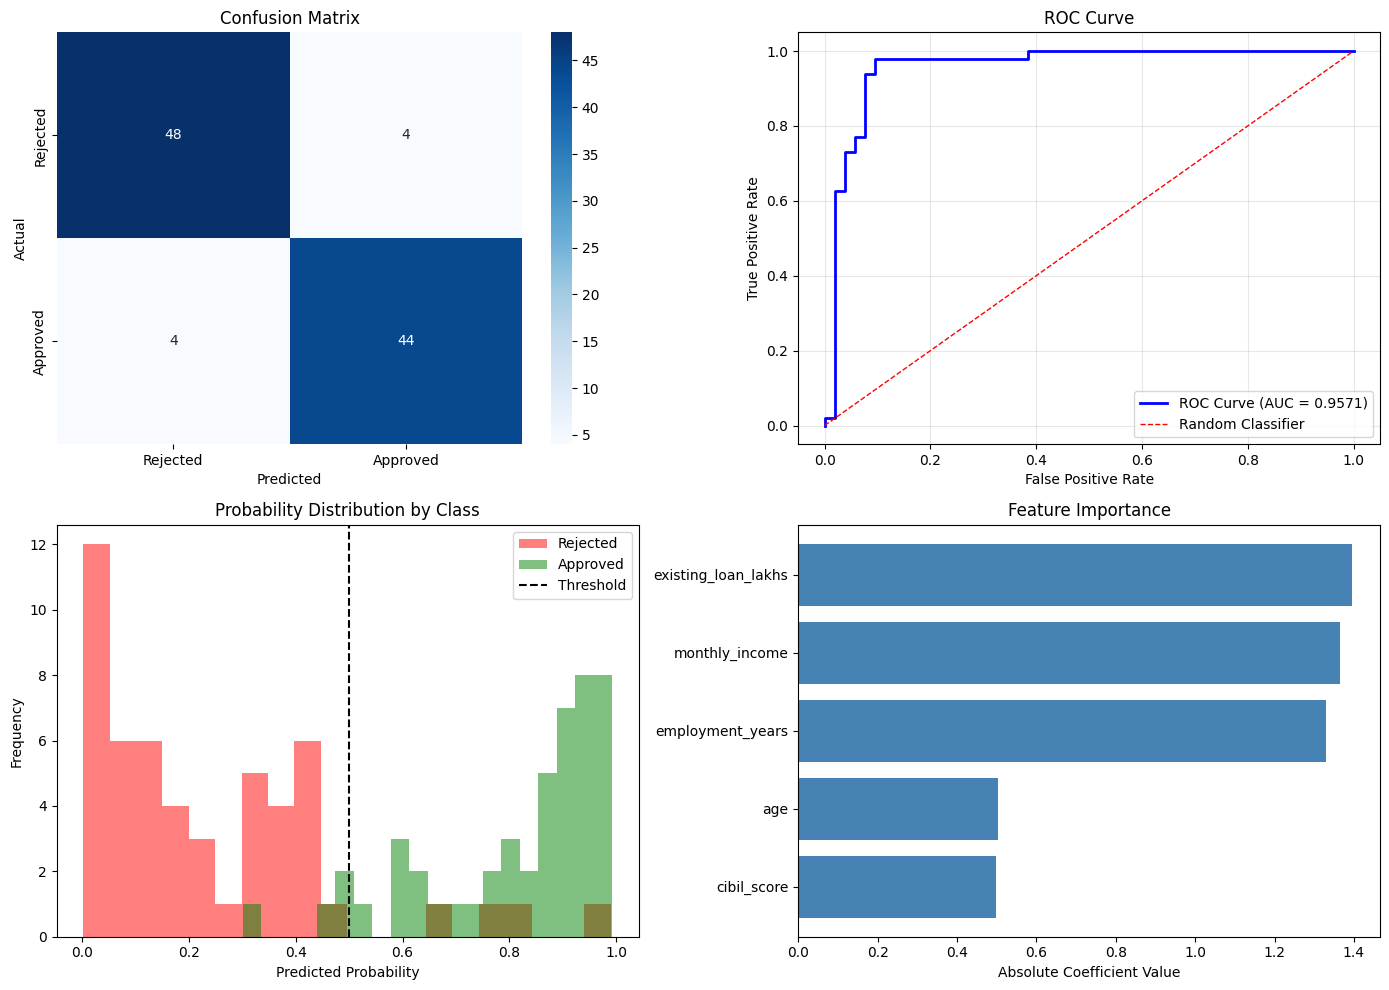


=== PREDICTION FOR NEW LOAN APPLICANTS ===

Applicant Details & Predictions:
──────────────────────────────────────────────────────────────────────

Applicant 1:
  Income: ₹80,000/month
  CIBIL: 780
  Existing Loans: ₹5.0 Lakhs
  Age: 35 years
  Employment: 10 years
  → Approval Probability: 84.9%
  → Decision: ✅ APPROVED

Applicant 2:
  Income: ₹35,000/month
  CIBIL: 550
  Existing Loans: ₹25.0 Lakhs
  Age: 45 years
  Employment: 3 years
  → Approval Probability: 1.9%
  → Decision: ❌ REJECTED

Applicant 3:
  Income: ₹120,000/month
  CIBIL: 820
  Existing Loans: ₹10.0 Lakhs
  Age: 28 years
  Employment: 5 years
  → Approval Probability: 91.2%
  → Decision: ✅ APPROVED


In [14]:
# Step 9: CROSS-VALIDATION
print(f"\n{'='*70}")
print(f"=== CROSS-VALIDATION (5-Fold Stratified) ===")
print(f"{'='*70}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='precision')
cv_recall = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='recall')
cv_f1 = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='f1')
cv_auc = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='roc_auc')

print(f"\nMetric          Mean ± Std")
print(f"{'─'*35}")
print(f"Accuracy:    {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"Precision:   {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"Recall:      {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"F1 Score:    {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"AUC-ROC:     {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# Step 10: VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title('Confusion Matrix')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
axes[0, 1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[0, 1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Probability Distribution
axes[1, 0].hist(y_test_prob[y_test==0], bins=20, alpha=0.5, label='Rejected', color='red')
axes[1, 0].hist(y_test_prob[y_test==1], bins=20, alpha=0.5, label='Approved', color='green')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
axes[1, 0].set_xlabel('Predicted Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Probability Distribution by Class')
axes[1, 0].legend()

# Plot 4: Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(model.coef_[0])
}).sort_values('Coefficient', ascending=True)
axes[1, 1].barh(feature_importance['Feature'], feature_importance['Coefficient'], color='steelblue')
axes[1, 1].set_xlabel('Absolute Coefficient Value')
axes[1, 1].set_title('Feature Importance')

plt.tight_layout()
plt.savefig('logistic_regression_evaluation.png', dpi=150)
plt.show()

# Step 11: PREDICT FOR NEW APPLICANTS
print(f"\n{'='*70}")
print(f"=== PREDICTION FOR NEW LOAN APPLICANTS ===")
print(f"{'='*70}")

new_applicants = pd.DataFrame({
    'monthly_income': [80000, 35000, 120000],
    'cibil_score': [780, 550, 820],
    'existing_loan_lakhs': [5, 25, 10],
    'age': [35, 45, 28],
    'employment_years': [10, 3, 5]
})

new_applicants_scaled = scaler.transform(new_applicants)
predictions = model.predict(new_applicants_scaled)
probabilities = model.predict_proba(new_applicants_scaled)[:, 1]

print("\nApplicant Details & Predictions:")
print("─" * 70)
for i in range(len(new_applicants)):
    print(f"\nApplicant {i+1}:")
    print(f"  Income: ₹{new_applicants.iloc[i]['monthly_income']:,}/month")
    print(f"  CIBIL: {new_applicants.iloc[i]['cibil_score']}")
    print(f"  Existing Loans: ₹{new_applicants.iloc[i]['existing_loan_lakhs']:.1f} Lakhs")
    print(f"  Age: {new_applicants.iloc[i]['age']} years")
    print(f"  Employment: {new_applicants.iloc[i]['employment_years']} years")
    print(f"  → Approval Probability: {probabilities[i]*100:.1f}%")
    print(f"  → Decision: {'✅ APPROVED' if predictions[i]==1 else '❌ REJECTED'}")

1️⃣ Accuracy (High-level but dangerous if used alone)
Training Accuracy: 93%
Testing Accuracy: 92%


What it means

The model predicts correctly 92 out of 100 cases on unseen data.

Train and test accuracy are close → no overfitting.

Hard truth
Accuracy alone is not enough in loan problems.
A model can be “accurate” and still lose money.

2️⃣ Confusion Matrix (THIS is the real story)
                 Predicted
              Rejected  Approved
Actual Rejected     48        4
Actual Approved      4       44


Let’s break it row by row.

True Negatives (TN) = 48

✔ Correctly rejected risky customers
👉 Bank avoided bad loans

False Positives (FP) = 4

❌ Approved risky customers
👉 Direct financial risk (most dangerous error)

False Negatives (FN) = 4

❌ Rejected good customers
👉 Lost business / unhappy customers

True Positives (TP) = 44

✔ Correctly approved good customers
👉 Healthy loans, profit

📌 Key insight
FP and FN are equal here → balanced model

3️⃣ Precision (Bank’s Risk Control Metric)
Precision = 0.9167


Formula

TP / (TP + FP)


Meaning

Of all loans we approved, 91.7% were actually safe

Why it matters

High precision → low bad-loan rate

Bank cares a LOT about this

👉 If precision drops → NPAs increase

4️⃣ Recall (Customer Coverage Metric)
Recall = 0.9167


Formula

TP / (TP + FN)


Meaning

Of all genuinely good customers, we approved 91.7%

Why it matters

High recall → fewer good customers rejected

Improves market reach & customer satisfaction

5️⃣ F1 Score (Balanced Performance)
F1 Score = 0.9167


What it is

Harmonic mean of Precision & Recall

Penalises imbalance

Interpretation

The model balances risk control and customer acquisition well

📌 Especially important when:

Costs of FP and FN both matter (like banking)

6️⃣ AUC-ROC (Model’s True Intelligence)
AUC-ROC = 0.9571


Meaning

Probability that model ranks a good customer higher than a bad one

0.5 = random, 1.0 = perfect

✅ 0.9571 = Excellent

Strong separation between approved & rejected customers

Threshold can be tuned safely

7️⃣ Classification Report (Consistency Check)

Everything is ~0.92:

Precision

Recall

F1

Accuracy

What this tells you

No class bias

No data leakage

No imbalance issue

8️⃣ Final Interview-Ready Summary (Say This)

“The model performs consistently across all metrics with 92% test accuracy. Precision and recall are both around 91.7%, meaning we control bad-loan risk while still approving most eligible customers. The AUC-ROC of 0.95 shows strong discrimination power, making this model reliable for loan approval decisions.”

9️⃣ Business Improvement Levers (Forward Thinking)

If this were production:

Increase Precision → reduce FP → safer bank

Increase Recall → more customers → higher revenue

Tune decision threshold based on risk appetite

In [15]:
# ============================================================
# EXAMPLE 1: STUDENT PASS/FAIL PREDICTION
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

# Create Data
np.random.seed(42)
n_students = 300

student_data = {
    'attendance_percent': np.random.randint(40, 100, n_students),
    'assignment_score': np.random.randint(20, 100, n_students),
    'study_hours_per_week': np.random.randint(5, 40, n_students),
    'previous_grade': np.random.randint(30, 100, n_students),
}
df = pd.DataFrame(student_data)

# Pass if weighted score > threshold
weighted_score = (
    df['attendance_percent'] * 0.2 +
    df['assignment_score'] * 0.3 +
    df['study_hours_per_week'] * 1 +
    df['previous_grade'] * 0.3
)
df['passed'] = (weighted_score > weighted_score.quantile(0.4)).astype(int)

print("=== Student Performance Data ===")
print(df.head())
print(f"\nPass Rate: {df['passed'].mean()*100:.1f}%")

# Prepare Data
X = df[['attendance_percent', 'assignment_score', 'study_hours_per_week', 'previous_grade']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# === EVALUATION ===
print(f"\n{'='*50}")
print("=== STUDENT PASS/FAIL PREDICTION EVALUATION ===")
print(f"{'='*50}")

print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"              Predicted")
print(f"            Fail   Pass")
print(f"Actual Fail  {cm[0,0]:3d}    {cm[0,1]:3d}")
print(f"Actual Pass  {cm[1,0]:3d}    {cm[1,1]:3d}")

# Cross-Validation
cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Predict for new student
print(f"\n=== PREDICT FOR NEW STUDENT ===")
new_student = {
    'attendance_percent': 75,
    'assignment_score': 65,
    'study_hours_per_week': 15,
    'previous_grade': 70
}
new_scaled = scaler.transform(pd.DataFrame([new_student]))
prob = model.predict_proba(new_scaled)[0][1]
pred = model.predict(new_scaled)[0]
print(f"Attendance: 75%, Assignments: 65, Study: 15 hrs/week, Previous: 70")
print(f"Pass Probability: {prob*100:.1f}%")
print(f"Prediction: {'✅ PASS' if pred==1 else '❌ FAIL'}")

=== Student Performance Data ===
   attendance_percent  assignment_score  study_hours_per_week  previous_grade  \
0                  78                92                    20              43   
1                  91                78                    18              93   
2                  68                89                    35              67   
3                  54                99                     9              66   
4                  82                22                    39              40   

   passed  
0       1  
1       1  
2       1  
3       1  
4       1  

Pass Rate: 60.0%

=== STUDENT PASS/FAIL PREDICTION EVALUATION ===

Accuracy: 96.67%
Precision: 0.9722
Recall: 0.9722
F1 Score: 0.9722

Confusion Matrix:
              Predicted
            Fail   Pass
Actual Fail   23      1
Actual Pass    1     35

Cross-Validation Accuracy: 0.9800 ± 0.0194

=== PREDICT FOR NEW STUDENT ===
Attendance: 75%, Assignments: 65, Study: 15 hrs/week, Previous: 70
Pass Probabili

In [16]:
# ============================================================
# EXAMPLE 2: TELECOM CUSTOMER CHURN PREDICTION
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_auc_score)
from sklearn.preprocessing import StandardScaler

# Create Data (Jio/Airtel style)
np.random.seed(42)
n_customers = 500

churn_data = {
    'monthly_recharge': np.random.choice([149, 199, 299, 399, 599, 999], n_customers),
    'data_usage_gb': np.random.uniform(1, 60, n_customers),
    'call_minutes': np.random.randint(50, 500, n_customers),
    'complaints_6months': np.random.randint(0, 8, n_customers),
    'tenure_months': np.random.randint(1, 60, n_customers),
}
df = pd.DataFrame(churn_data)

# Churn logic
churn_score = (
    -0.002 * df['monthly_recharge'] +
    -0.02 * df['data_usage_gb'] +
    0.3 * df['complaints_6months'] +
    -0.05 * df['tenure_months']
)
churn_prob = 1 / (1 + np.exp(-churn_score))
df['churned'] = (np.random.random(n_customers) < churn_prob).astype(int)

print("=== Telecom Customer Data ===")
print(df.head())
print(f"\nChurn Rate: {df['churned'].mean()*100:.1f}%")

# Prepare Data
X = df.drop('churned', axis=1)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# === EVALUATION ===
print(f"\n{'='*50}")
print("=== CHURN PREDICTION EVALUATION ===")
print(f"{'='*50}")

print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  → Of predicted churners, {precision_score(y_test, y_pred)*100:.1f}% actually churned")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"  → We identified {recall_score(y_test, y_pred)*100:.1f}% of actual churners")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

# Business Impact
print(f"\n=== BUSINESS IMPACT ===")
cm = confusion_matrix(y_test, y_pred)
fn = cm[1, 0]  # Churners we missed
fp = cm[0, 1]  # Non-churners we flagged
print(f"Churners we MISSED (FN): {fn}")
print(f"  → Lost revenue potential: ₹{fn * 299 * 12:,}/year (assuming ₹299/month)")
print(f"Non-churners wrongly flagged (FP): {fp}")
print(f"  → Unnecessary retention offers: {fp} customers")

# Predict for customers at risk
print(f"\n=== IDENTIFY HIGH-RISK CUSTOMERS ===")
high_risk = y_prob > 0.7
print(f"Customers with >70% churn probability: {high_risk.sum()}")
print(f"ACTION: Send retention offers to these customers!")

=== Telecom Customer Data ===
   monthly_recharge  data_usage_gb  call_minutes  complaints_6months  \
0               399      11.218910           386                   3   
1               599      26.597247           133                   7   
2               299      24.511779           410                   4   
3               599      37.335156           226                   3   
4               599      38.470525           197                   4   

   tenure_months  churned  
0              2        0  
1             35        1  
2             37        1  
3              5        1  
4              1        1  

Churn Rate: 19.4%

=== CHURN PREDICTION EVALUATION ===

Accuracy: 83.00%
Precision: 0.7500
  → Of predicted churners, 75.0% actually churned
Recall: 0.1579
  → We identified 15.8% of actual churners
F1 Score: 0.2609
AUC-ROC: 0.8142

=== BUSINESS IMPACT ===
Churners we MISSED (FN): 16
  → Lost revenue potential: ₹57,408/year (assuming ₹299/month)
Non-churners wrongly

In [19]:
# ============================================================
# EXAMPLE 3: DIABETES PREDICTION
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_auc_score)
from sklearn.preprocessing import StandardScaler

# Create Data
np.random.seed(42)
n_patients = 400

diabetes_data = {
    'age': np.random.randint(25, 70, n_patients),
    'bmi': np.random.uniform(18, 40, n_patients),
    'fasting_glucose': np.random.randint(70, 200, n_patients),
    'hba1c': np.random.uniform(4.5, 9, n_patients),
    'family_history': np.random.choice([0, 1], n_patients, p=[0.7, 0.3]),
    'physical_activity': np.random.choice([1, 2, 3], n_patients),  # 1=Low, 2=Medium, 3=High
}
df = pd.DataFrame(diabetes_data)

# Diabetes logic
diabetes_score = (
    0.02 * df['age'] +
    0.1 * df['bmi'] +
    0.01 * df['fasting_glucose'] +
    0.5 * df['hba1c'] +
    0.5 * df['family_history'] +
    -0.3 * df['physical_activity']
)
df['diabetic'] = (diabetes_score > diabetes_score.quantile(0.7)).astype(int)

print("=== Patient Health Data ===")
print(df.head())
print(f"\nDiabetes Rate: {df['diabetic'].mean()*100:.1f}%")

# Prepare Data
X = df.drop('diabetic', axis=1)
y = df['diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# === EVALUATION ===
print(f"\n{'='*50}")
print("=== DIABETES PREDICTION EVALUATION ===")
print(f"{'='*50}")

print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

# For medical diagnosis, RECALL is critical!
print(f"\n⚠️ CRITICAL METRIC - RECALL (Sensitivity): {recall_score(y_test, y_pred):.4f}")
print(f"  → We detected {recall_score(y_test, y_pred)*100:.1f}% of diabetic patients")
print(f"  → Missing diabetic patients is DANGEROUS!")

print(f"\nPrecision (Specificity): {precision_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix Analysis
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"              Predicted")
print(f"            Non-Diab  Diabetic")
print(f"Actual Non   {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Actual Diab  {cm[1,0]:4d}      {cm[1,1]:4d}")

fn = cm[1, 0]  # Diabetics we missed
print(f"\n⚠️ FALSE NEGATIVES (Missed Diabetics): {fn}")
print(f"   These patients might not get treatment!")

# Predict for new patient
print(f"\n=== PREDICT FOR NEW PATIENT ===")
new_patient = {
    'age': 45,
    'bmi': 28.5,
    'fasting_glucose': 140,
    'hba1c': 6.8,
    'family_history': 1,
    'physical_activity': 1
}
new_scaled = scaler.transform(pd.DataFrame([new_patient]))
prob = model.predict_proba(new_scaled)[0][1]
print(f"Age: 45, BMI: 28.5, Fasting Glucose: 140, HbA1c: 6.8")
print(f"Family History: Yes, Physical Activity: Low")
print(f"\n🏥 Diabetes Risk: {prob*100:.1f}%")
print(f"Recommendation: {'Immediate consultation advised!' if prob > 0.5 else 'Regular monitoring'}")


=== Patient Health Data ===
   age        bmi  fasting_glucose     hba1c  family_history  \
0   63  31.703590              169  5.537561               0   
1   53  19.877644              146  8.237891               0   
2   39  19.136998               72  5.041524               0   
3   67  29.689802               79  4.711254               0   
4   32  29.893973               74  6.228408               0   

   physical_activity  diabetic  
0                  2         0  
1                  2         0  
2                  3         0  
3                  1         0  
4                  2         0  

Diabetes Rate: 30.0%

=== DIABETES PREDICTION EVALUATION ===

Accuracy: 96.25%

⚠️ CRITICAL METRIC - RECALL (Sensitivity): 0.8750
  → We detected 87.5% of diabetic patients
  → Missing diabetic patients is DANGEROUS!

Precision (Specificity): 1.0000
F1 Score: 0.9333
AUC-ROC: 1.0000

Confusion Matrix:
              Predicted
            Non-Diab  Diabetic
Actual Non     56         0
Act